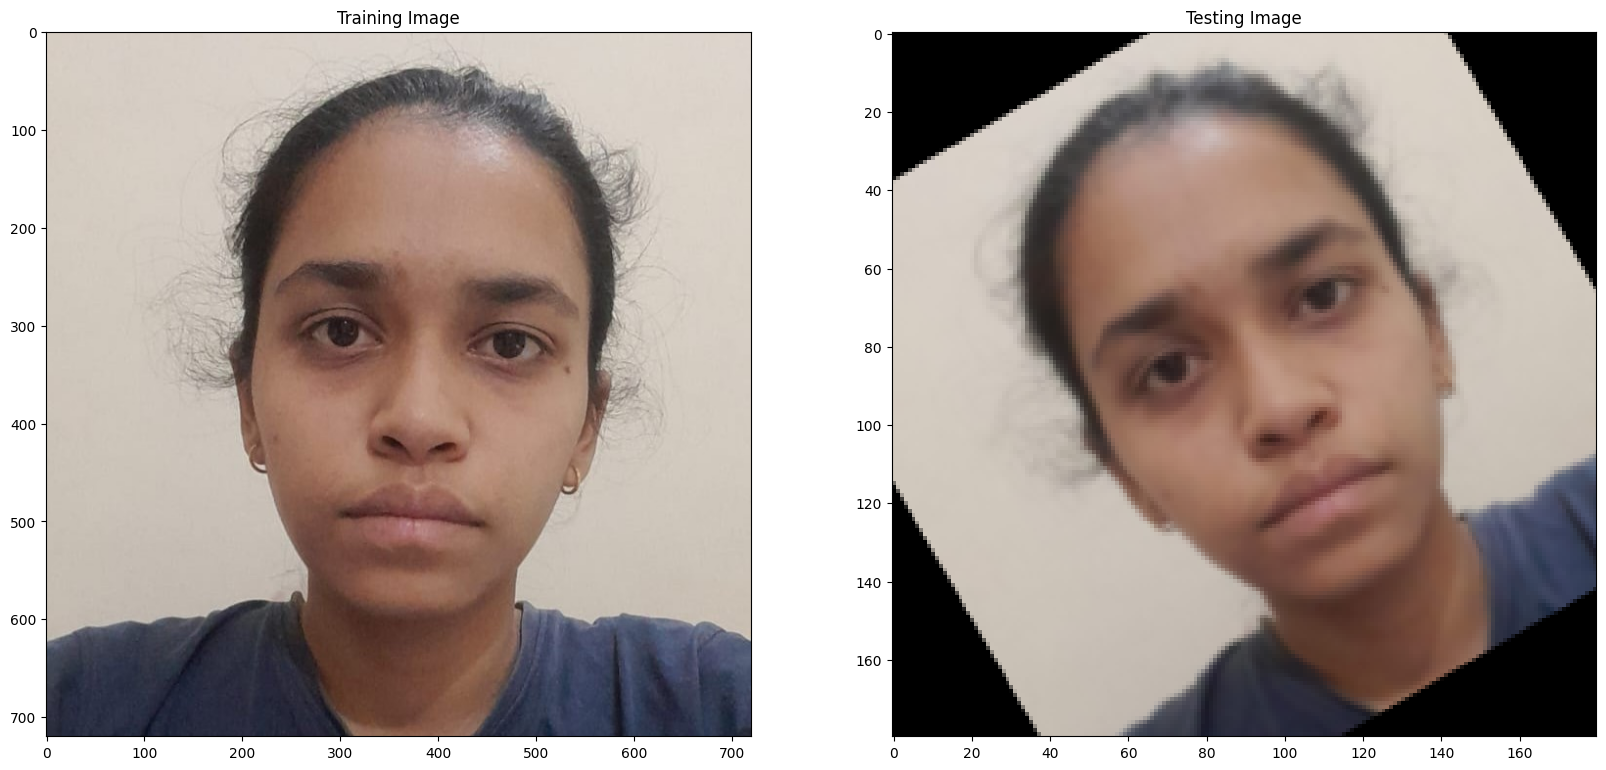

In [ ]:
import cv2  # import OpenCV for image processing
import matplotlib.pyplot as plt  # import matplotlib for visualization
import numpy as np  # import numpy for numerical operations

# load the image from the specified path
image1 = cv2.imread('/content/image.jpeg')

# convert the training image from BGR (OpenCV default) to RGB
training_image = cv2.cvtColor(image1, cv2.COLOR_BGR2RGB)

# convert the training image to grayscale for further processing
training_gray = cv2.cvtColor(training_image, cv2.COLOR_RGB2GRAY)

# create a test image by applying scale invariance (reducing size)
test_image = cv2.pyrDown(training_image)  # downsample the image once
test_image = cv2.pyrDown(test_image)  # downsample again to make it even smaller

# get the number of rows and columns of the test image
num_rows, num_cols = test_image.shape[:2]

# create a rotation matrix to rotate the image by 30 degrees
rotation_matrix = cv2.getRotationMatrix2D((num_cols / 2, num_rows / 2), 30, 1)

# apply the rotation to the test image
test_image = cv2.warpAffine(test_image, rotation_matrix, (num_cols, num_rows))

# convert the test image to grayscale
test_gray = cv2.cvtColor(test_image, cv2.COLOR_RGB2GRAY)

# create a figure with two subplots to display the training and test images
fx, plots = plt.subplots(1, 2, figsize=(20, 10))

# display the training image with a title
plots[0].set_title("Training Image")
plots[0].imshow(training_image)

# display the test image with a title
plots[1].set_title("Testing Image")
plots[1].imshow(test_image)

# show the images (required for Python scripts)
plt.show()


Number of Keypoints Detected In The Training Image:  815
Number of Keypoints Detected In The Query Image:  86


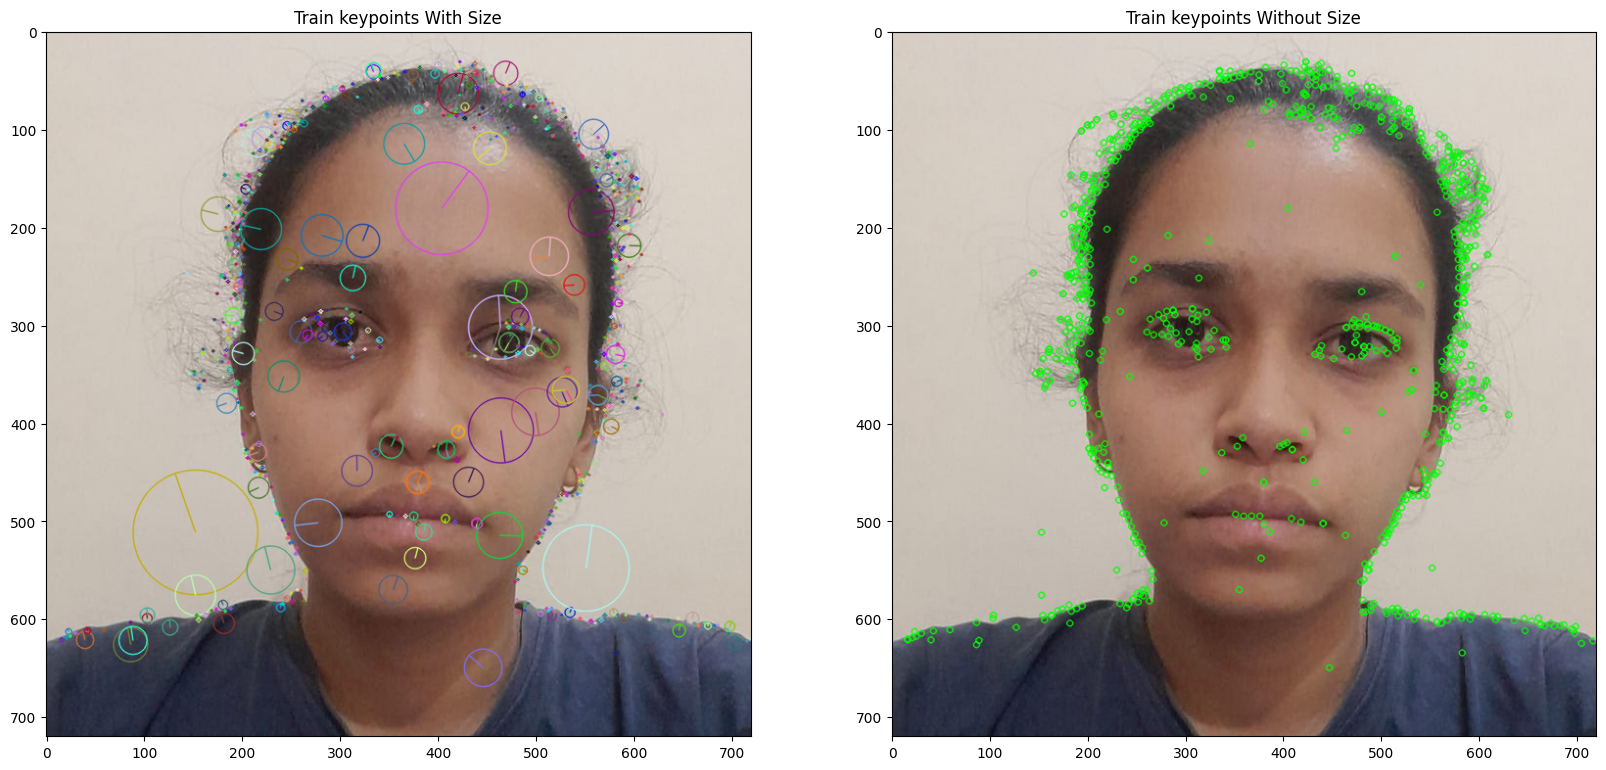

In [ ]:
# create sift detector (fixed: removed `xfeatures2d` as it's part of opencv contrib)
sift = cv2.SIFT_create()

# detect and compute sift features in the training and test images
train_keypoints, train_descriptor = sift.detectAndCompute(training_gray, None)
test_keypoints, test_descriptor = sift.detectAndCompute(test_gray, None)

# copy the original training image to draw keypoints
keypoints_without_size = training_image.copy()
keypoints_with_size = training_image.copy()

# draw keypoints without size information (fixed: assign the returned image)
cv2.drawKeypoints(training_image, train_keypoints, keypoints_without_size, color = (0, 255, 0))

# draw keypoints with size and orientation information (fixed: assign the returned image)
cv2.drawKeypoints(training_image, train_keypoints, keypoints_with_size, flags = cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)

# display images with and without keypoint size
fx, plots = plt.subplots(1, 2, figsize=(20,10))

# plot image with keypoints and size information
plots[0].set_title("Train keypoints With Size")
plots[0].imshow(keypoints_with_size, cmap='gray')

# plot image with keypoints without size information
plots[1].set_title("Train keypoints Without Size")
plots[1].imshow(keypoints_without_size, cmap='gray')

# print the number of keypoints detected in the training image
print("Number of Keypoints Detected In The Training Image: ", len(train_keypoints))

# print the number of keypoints detected in the query image
print("Number of Keypoints Detected In The Query Image: ", len(test_keypoints))


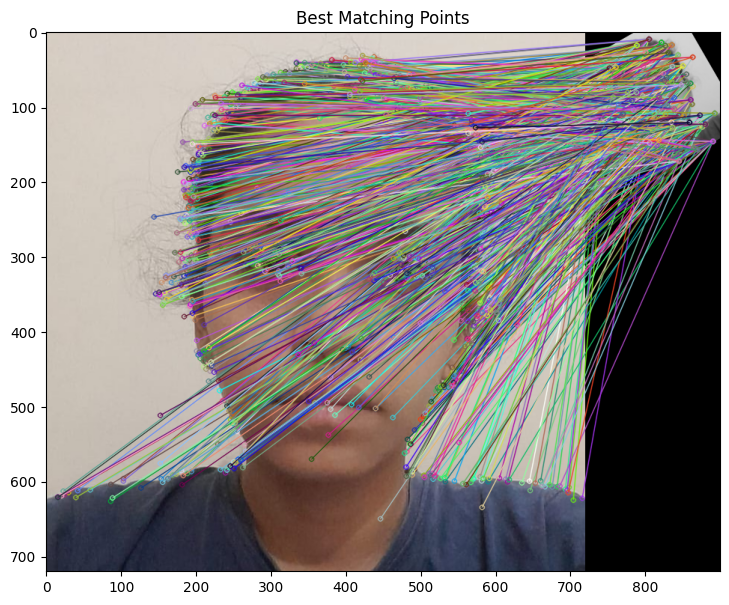


Number of Matching Keypoints Between The Training and Query Images:  815


In [ ]:
# create a brute force matcher object with l1 norm and without cross check
bf = cv2.BFMatcher(cv2.NORM_L1, crossCheck = False)

# perform the matching between the sift descriptors of the training image and the test image
matches = bf.match(train_descriptor, test_descriptor)

# sort the matches based on the distance (shorter distance means better match)
matches = sorted(matches, key = lambda x : x.distance)

# draw the best matching points between the training and test images
result = cv2.drawMatches(training_image, train_keypoints, test_gray, test_keypoints, matches, test_gray, flags = 2)

# display the best matching points
plt.rcParams['figure.figsize'] = [14.0, 7.0]
plt.title('Best Matching Points')
plt.imshow(result)
plt.show()

# print total number of matching keypoints between the training and query images
print("\nNumber of Matching Keypoints Between The Training and Query Images: ", len(matches))
